# Marketplace Pricing Forecasting: SKU Features and ARIMA

This notebook focuses on feature engineering for SKU-level analysis and ARIMA-based time-series forecasting.

## Goal
Build complementary time-series baselines and product features to compare with machine-learning-based forecasting approaches.

## Main components
- Condition variable construction
- Residual and product feature construction
- SKU definition
- Frequency-based grouping
- ARIMA forecasting workflow

# 1. Data Import

In [2]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from numpy import random; random.seed(100)
from scipy import stats
from scipy import optimize  
from scipy.stats import norm
from matplotlib import rcParams
from joblib import Parallel, delayed
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

import statsmodels.api as sm
import statsmodels.stats.api as sms
import statsmodels.formula.api as smf
# from fitter import Fitter # might require install, numpy version matters
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [3]:
df = pd.read_csv('sku_merged.csv')

In [ ]:
df.head()

In [ ]:
df.columns

In [6]:
df.describe()

,Market Price (From Day of Sale),Product ID,Quantity,Total Product Price,Unit Price,Condition Score,Residual,Log Price
count,1.949552e+06,1.949552e+06,1.949552e+06,1.949552e+06,1.949552e+06,1.949552e+06,1.949552e+06,1.949552e+06
mean,7.872934e+00,3.598986e+05,1.800553e+00,1.018410e+01,7.760399e+00,4.680706e+00,-1.125355e-01,1.206776e+00
std,2.594156e+01,2.294334e+05,3.642328e+00,3.395517e+01,2.548314e+01,6.934508e-01,5.091455e+00,1.151823e+00
min,1.000000e-02,3.484000e+03,1.000000e+00,1.000000e-02,1.000000e-02,1.000000e+00,-8.450000e+02,9.950331e-03
25%,2.900000e-01,1.828310e+05,1.000000e+00,4.200000e-01,2.600000e-01,4.000000e+00,-1.800000e-01,2.311117e-01
50%,1.280000e+00,4.788190e+05,1.000000e+00,1.800000e+00,1.200000e+00,5.000000e+00,-1.000000e-02,7.884574e-01
75%,6.000000e+00,5.970270e+05,2.000000e+00,7.900000e+00,5.990000e+00,5.000000e+00,1.300000e-01,1.944481e+00
max,9.999900e+02,6.306890e+05,9.940000e+02,2.295000e+03,1.099970e+03,6.000000e+00,9.447400e+02,7.003947e+00


In [ ]:
df.info()

# 2、ARIMA Tests

In [ ]:
warnings.simplefilter("ignore", ConvergenceWarning)

# --- Step 1: Determine the order of differencing needed to make the series stationary (ADF test) ---
def get_diff_order(y):
    d = 0  
    while True:
        pval = adfuller(y.dropna())[1]  
        if pval < 0.05:
            return d  
        y = y.diff()  
        d += 1
        if d > 2:
            return d  

# --- Step 2: Fit the best ARIMA model for an individual SKU ---
def fit_arima_manual(sku, group):
    series = group.sort_values('Ordered At Date')['Unit Price']
    if len(series) < 40 or series.var() == 0:
        return None
    y = np.log(series)
    d = get_diff_order(y)
    best_aic = np.inf       
    best_order = None     
    best_model = None       

    for p in range(3):
        for q in range(3):
            try:
                model = ARIMA(y, order=(p, d, q)).fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p, d, q)
                    best_model = model
            except:
                continue                  
    
    if best_model is None:
        return {'SKU': sku, 'error': 'no model converged'}
    return {
        'SKU': sku,
        'n_obs': len(series),         
        'order': best_order,          
        'AIC': best_model.aic,        
        'BIC': best_model.bic,        
        'converged': True             
    }

# --- Step 3: Run the modeling function for all SKUs in parallel ---
def bulk_fit_manual(df):
    results = Parallel(n_jobs=-1, verbose=5)(  
        delayed(fit_arima_manual)(sku, group)  
        for sku, group in df.groupby('SKU')    
    )
    return pd.DataFrame([r for r in results if r is not None])  

In [ ]:
# Load the uploaded ARIMA results file
df = pd.read_csv('arima_sku_summary.csv')

# Basic summary
summary = {
    "row_count": len(df),
    "columns": df.columns.tolist(),
    "missing_by_column": df.isnull().sum(),
    "converged_counts": df['converged'].value_counts(dropna=False) if 'converged' in df.columns else "No 'converged' column",
    "order_examples": df['order'].value_counts().head(10) if 'order' in df.columns else "No 'order' column",
    "forecast_price_stats": df['forecast_price'].describe() if 'forecast_price' in df.columns else "No 'forecast_price' column"
}

summary

# 3、Regression

In [15]:
warnings.simplefilter("ignore", ConvergenceWarning)

# --- Step 1: ADF test ---
def get_diff_order(y):
    d = 0  
    while True:
        pval = adfuller(y.dropna())[1]  
        if pval < 0.05:
            return d 
        y = y.diff()  
        d += 1
        if d > 2:
            return d 

# --- Step 2: Forecast the final price point ---
def fit_arima_manual(sku, group):
    group = group.sort_values('Ordered At Date')
    series = group['Unit Price']

    if len(series) < 40 or series.var() == 0:
        return None

    y = np.log(series)

    d = get_diff_order(y)

    best_aic = np.inf       
    best_order = None       
    best_model = None       

    for p in range(3):
        for q in range(3):
            try:
                model = ARIMA(y, order=(p, d, q)).fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p, d, q)
                    best_model = model
            except:
                continue

    if best_model is None:
        return {'SKU': sku, 'error': 'no model converged'}

    y_train = y.iloc[:-1]  
    try:
        pred_model = ARIMA(y_train, order=best_order).fit()
        forecast_log = pred_model.forecast(steps=1).iloc[0]  
        forecast_price = np.exp(forecast_log)                
        actual_price = series.iloc[-1]                       
        residual = forecast_price - actual_price             
    except:
        forecast_price = np.nan
        residual = np.nan

    try:
        market_price = group['Market Price (From Day of Sale)'].iloc[-1]
    except:
        market_price = np.nan

    return {
        'SKU': sku,
        'n_obs': len(series),
        'order': best_order,
        'AIC': best_model.aic,
        'BIC': best_model.bic,
        'forecast_price': forecast_price,
        'actual_price': actual_price,
        'residual': residual,
        'market_price': market_price,
        'converged': True
    }

# --- Step 3: Run the modeling function ---
def bulk_fit_manual(df):
    results = Parallel(n_jobs=-1, verbose=5)(
        delayed(fit_arima_manual)(sku, group)
        for sku, group in df.groupby('SKU')
    )
    return pd.DataFrame([r for r in results if r is not None])


In [ ]:
results = bulk_fit_manual(df)

In [17]:
results.head()

,SKU,n_obs,order,AIC,BIC,forecast_price,actual_price,residual,market_price,converged
0,102715 Unopened,254,"(1, 0, 1)",142.028783,156.178120,201.833845,198.45,3.383845,211.48,True
1,110418 Unopened,189,"(2, 1, 2)",-632.184808,-616.002598,142.838652,117.00,25.838652,141.14,True
2,114832 Unopened,163,"(0, 1, 1)",-618.024671,-611.849478,399.126464,400.00,-0.873536,397.80,True
3,11674 Heavily Played,113,"(1, 1, 2)",154.282166,165.156161,0.774158,1.26,-0.485842,0.78,True
4,11674 Lightly Played,823,"(1, 1, 1)",483.894109,498.029330,1.376274,1.37,0.006274,1.50,True


# 4、Evaluate performance

In [6]:
results = pd.read_csv('arima_results.csv')

In [8]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,              
)

# ------------------- RMSE -------------------
arima_rmse  = np.sqrt(mean_squared_error(df_eval['actual_price'], df_eval['forecast_price']))
market_rmse = np.sqrt(mean_squared_error(df_eval['actual_price'], df_eval['market_price']))

# ------------------- MAE -------------------- 
arima_mae  = mean_absolute_error(df_eval['actual_price'], df_eval['forecast_price'])
market_mae = mean_absolute_error(df_eval['actual_price'], df_eval['market_price'])

# ------------------- MAPE -------------------
arima_mape  = mean_absolute_percentage_error(df_eval['actual_price'], df_eval['forecast_price']) * 100
market_mape = mean_absolute_percentage_error(df_eval['actual_price'], df_eval['market_price']) * 100

print({
    'ARIMA_RMSE' : arima_rmse,
    'Market_RMSE': market_rmse,
    'ARIMA_MAE'  : arima_mae,       
    'Market_MAE' : market_mae,      
    'ARIMA_MAPE' : arima_mape,
    'Market_MAPE': market_mape
})


{'ARIMA_RMSE': 5.862511383680295, 'Market_RMSE': 4.439914270945579, 'ARIMA_MAE': 0.8660769054652181, 'Market_MAE': 0.8491021432709017, 'ARIMA_MAPE': 39.01493315550365, 'Market_MAPE': 47.839216582228055}


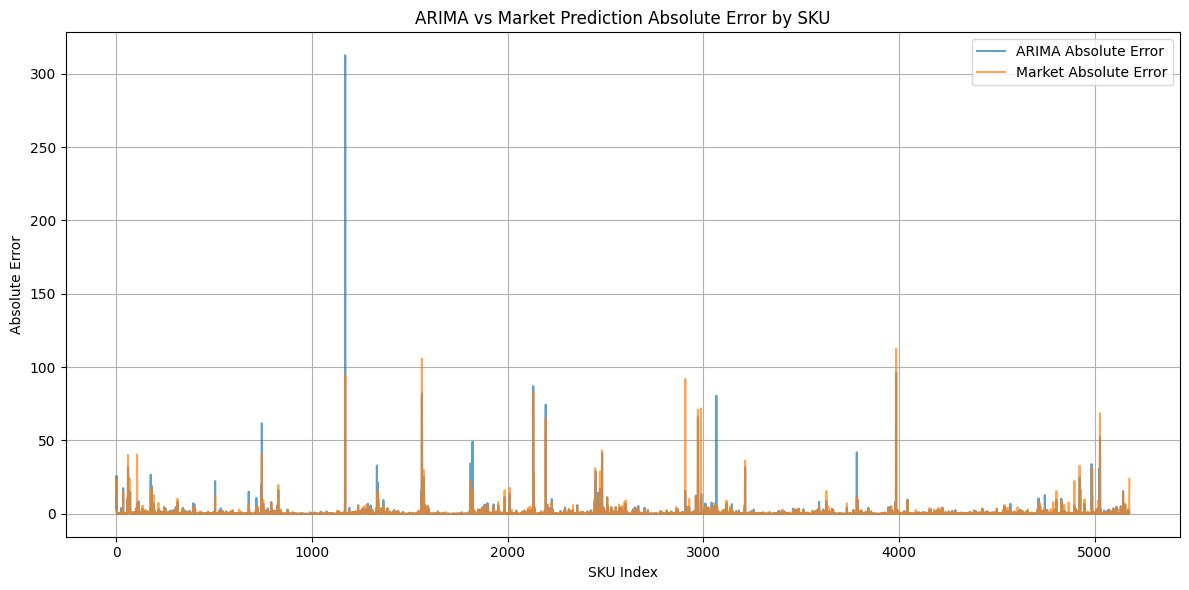

In [19]:
df_eval['ARIMA_AE'] = (df_eval['forecast_price'] - df_eval['actual_price']).abs()
df_eval['Market_AE'] = (df_eval['market_price'] - df_eval['actual_price']).abs()

plt.figure(figsize=(12, 6))
plt.plot(df_eval['ARIMA_AE'].values, label='ARIMA Absolute Error', alpha=0.7)
plt.plot(df_eval['Market_AE'].values, label='Market Absolute Error', alpha=0.7)
plt.title('ARIMA vs Market Prediction Absolute Error by SKU')
plt.xlabel('SKU Index')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_eval.head()

In [ ]:
df_eval.describe()

In [22]:
sku_features = pd.read_csv(r'sku_features.csv')

In [23]:
df_eval['SKU'] = df_eval['SKU'].astype(str)
sku_features['SKU'] = sku_features['SKU'].astype(str)

merged = pd.merge(df_eval, sku_features, on='SKU', how='left')


In [26]:
merged['Improvement'] = merged['Market_AE'] - merged['ARIMA_AE']
merged['Better_ARIMA'] = merged['Improvement'] > 0

group_stats = merged.groupby('Better_ARIMA')[[
    'Mean_Price', 'Price_Std', 'Log_Price_Std',
    'Sales', 'Frequency_TradeDays', 'MAPE'
]].mean()

print(group_stats)

              Mean_Price  Price_Std  Log_Price_Std       Sales  \
Better_ARIMA                                                     
False           5.617604   1.602028       0.177668  368.057132   
True            7.165871   1.869725       0.177319  340.019592   

              Frequency_TradeDays       MAPE  
Better_ARIMA                                  
False                    3.656058  40.717294  
True                     3.949362  53.606900  


In [ ]:
merged.head()

In [ ]:
merged.columns

# 5、Performance evaluation visualization

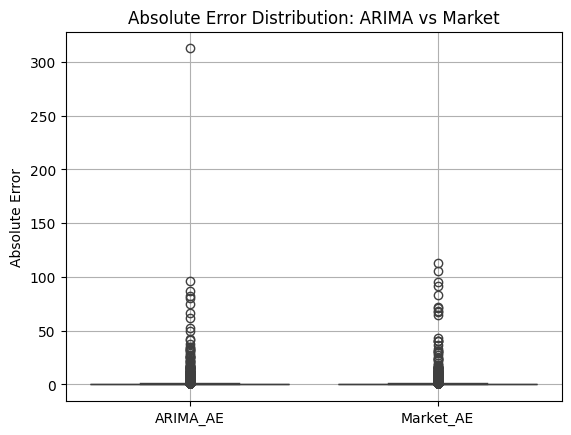

In [33]:
# 1. Boxplot: ARIMA vs Market
sns.boxplot(data=merged[['ARIMA_AE', 'Market_AE']])
plt.title('Absolute Error Distribution: ARIMA vs Market')
plt.ylabel('Absolute Error')
plt.grid(True)
plt.show()

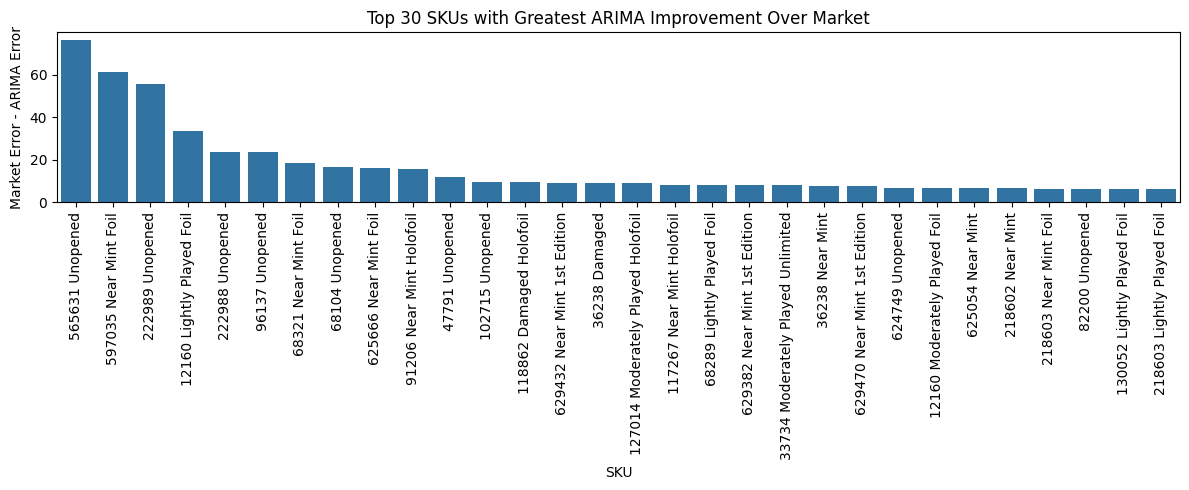

In [34]:
# 2
top_diff = merged.sort_values('Improvement', ascending=False).head(30)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_diff, x='SKU', y='Improvement')
plt.xticks(rotation=90)
plt.title('Top 30 SKUs with Greatest ARIMA Improvement Over Market')
plt.ylabel('Market Error - ARIMA Error')
plt.tight_layout()
plt.show()

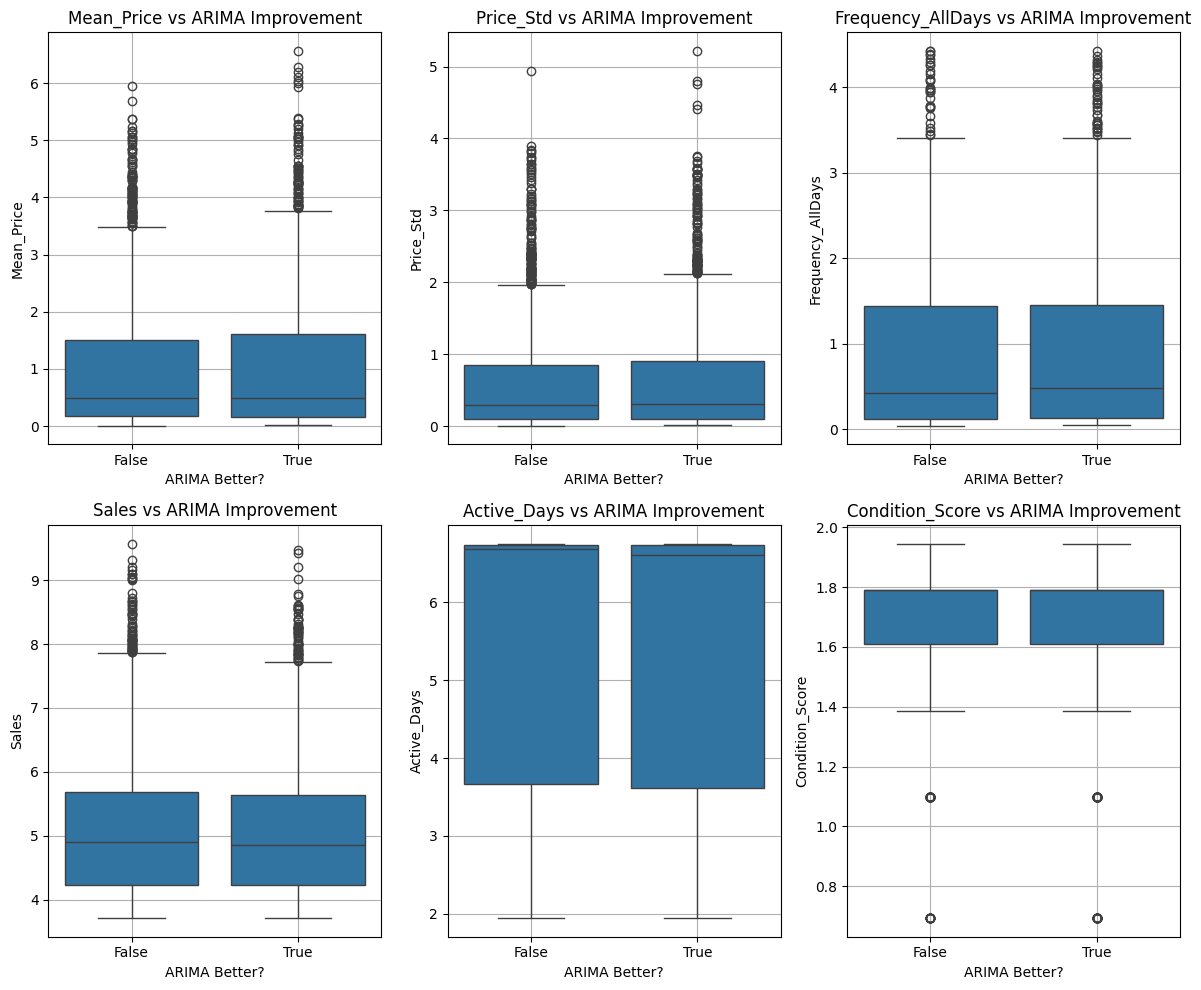

In [43]:
# 3
features = ['Mean_Price', 'Price_Std', 'Frequency_AllDays', 'Sales', 'Active_Days', 'Condition_Score']

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x='Better_ARIMA', y=np.log1p(merged[feat]), data=merged, ax=axes[i])
    axes[i].set_title(f'{feat} vs ARIMA Improvement')
    axes[i].set_xlabel('ARIMA Better?')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

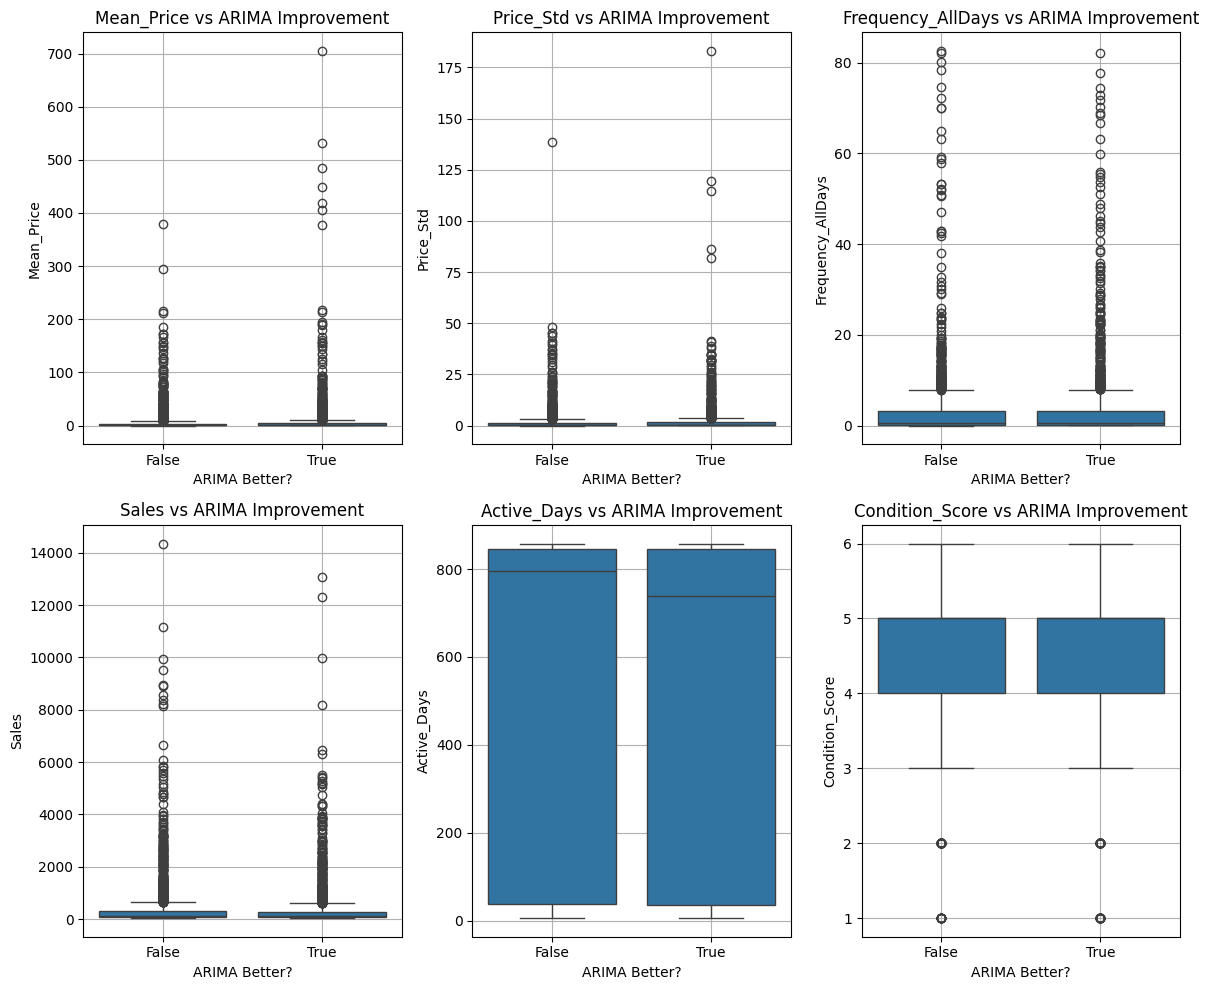

In [44]:
# 4
features = ['Mean_Price', 'Price_Std', 'Frequency_AllDays', 'Sales', 'Active_Days', 'Condition_Score']

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x='Better_ARIMA', y=merged[feat], data=merged, ax=axes[i])
    axes[i].set_title(f'{feat} vs ARIMA Improvement')
    axes[i].set_xlabel('ARIMA Better?')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [45]:
from scipy.stats import ttest_ind

features = ['Mean_Price', 'Price_Std', 'Frequency_AllDays', 'Sales', 'Active_Days', 'Condition_Score']

t_test_results = []

for feat in features:
    group_true = merged.loc[merged['Better_ARIMA'], feat].dropna()
    group_false = merged.loc[~merged['Better_ARIMA'], feat].dropna()
    
    t_stat, p_val = ttest_ind(group_true, group_false, equal_var=False)
    
    t_test_results.append({
        'Feature': feat,
        'Group_True_Mean': group_true.mean(),
        'Group_False_Mean': group_false.mean(),
        'T-Statistic': t_stat,
        'P-Value': p_val
    })

t_test_df = pd.DataFrame(t_test_results)

t_test_df

,Feature,Group_True_Mean,Group_False_Mean,T-Statistic,P-Value
0,Mean_Price,7.165871,5.617604,2.146295,0.031909
1,Price_Std,1.869725,1.602028,1.645724,0.099891
2,Frequency_AllDays,3.125564,2.824291,1.534712,0.124917
3,Sales,340.019592,368.057132,-1.245923,0.212849
4,Active_Days,485.766094,515.257282,-2.823850,0.004763
5,Condition_Score,4.528189,4.535101,-0.304777,0.760548


If P-Value < 0.05, then there is significant difference between two groups     
have significant difference：mean price, active days, price std

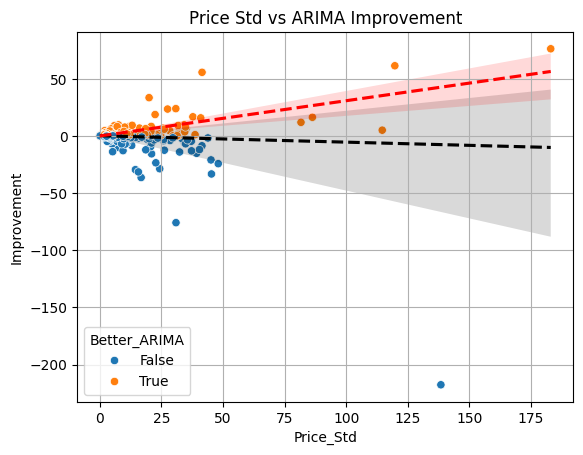

In [48]:
# 4. MAPE vs Price_Std
sns.scatterplot(data=merged, x='Price_Std', y='Improvement', hue='Better_ARIMA')

sns.regplot(data=merged, x='Price_Std', y='Improvement', scatter=False, color='black', line_kws={'linestyle': 'dashed'})

sns.regplot(data=merged[merged['Better_ARIMA']], x='Price_Std', y='Improvement', scatter=False, color='red', line_kws={'linestyle': 'dashed'})

plt.title('Price Std vs ARIMA Improvement')
plt.grid(True)
plt.show()


If ARIMA performs better, then the greater the price volatility, the larger its improvement relative to the original algorithm.

In [11]:
forecast_df.to_csv('arima_forecast_results.csv', index=False)

In [ ]:
arima_results = pd.read_csv(r'arima_forecast_results.csv')

In [ ]:
forecast_df = pd.read_csv(r"arima_sku_summary.csv")